# Task 1
Verify your Google Cloud environment setup, including capturing proof of your active cloud notebook instance or billing credit balance.
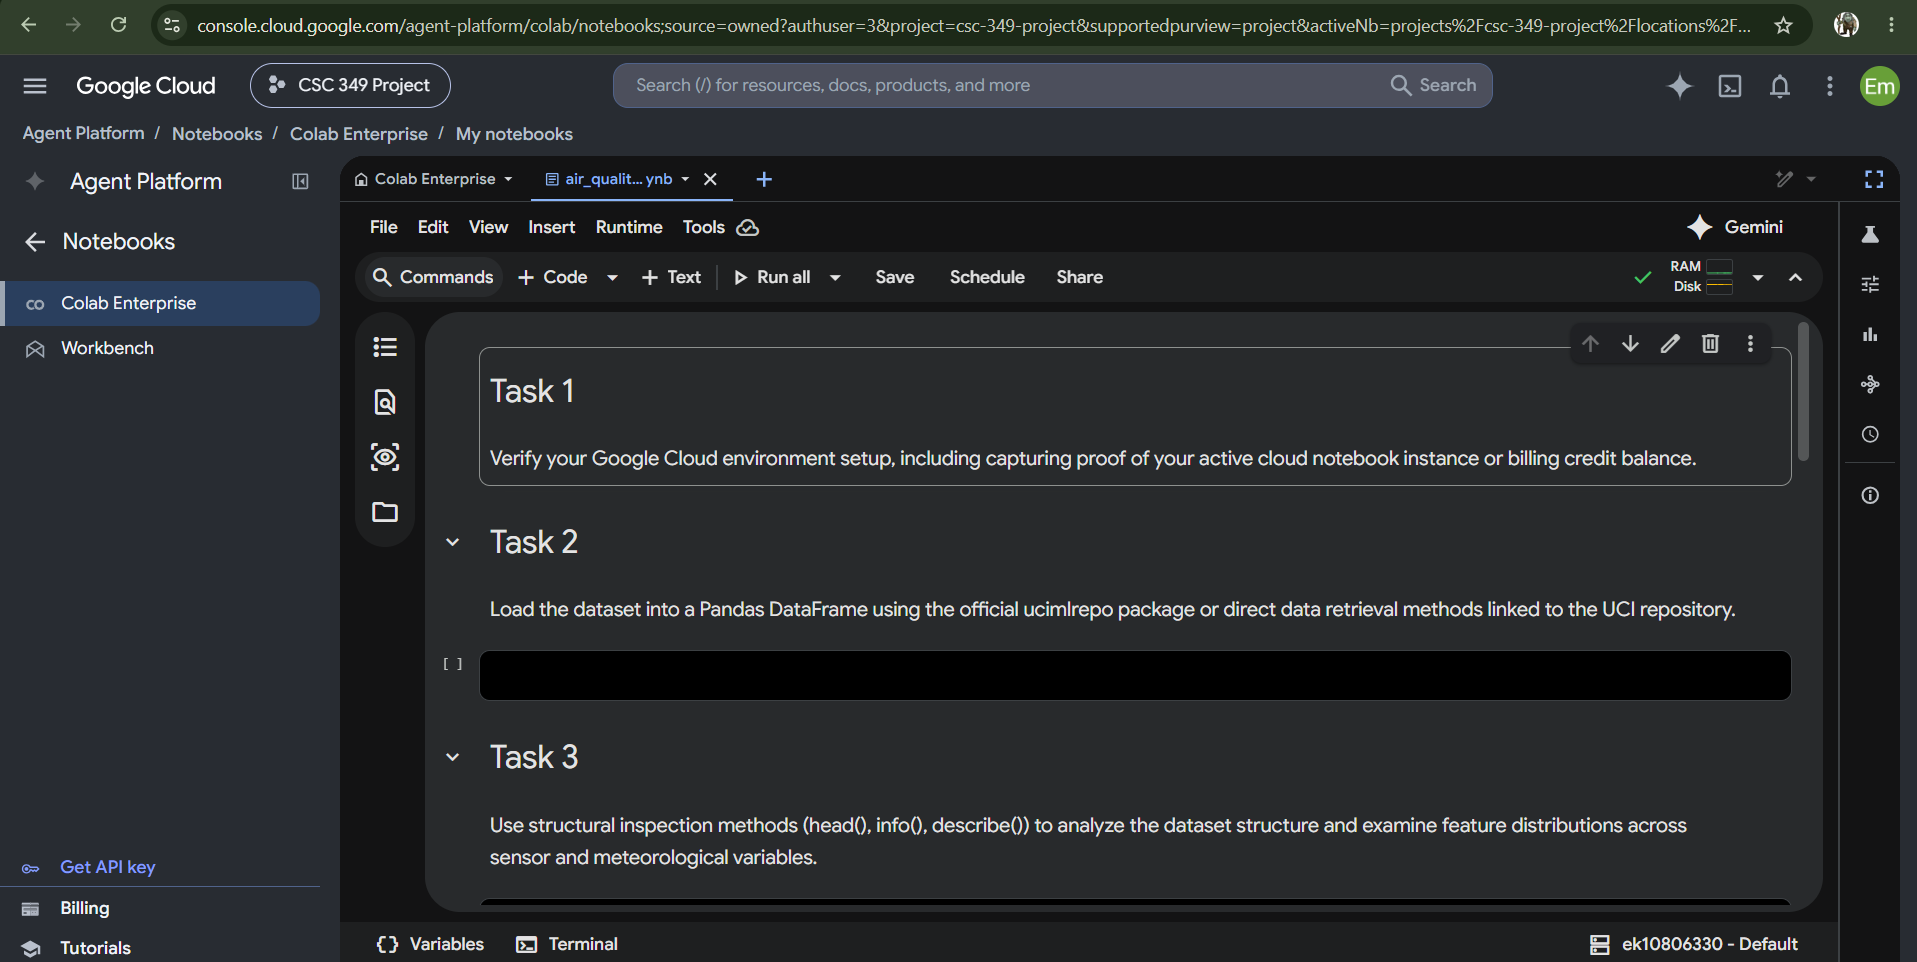
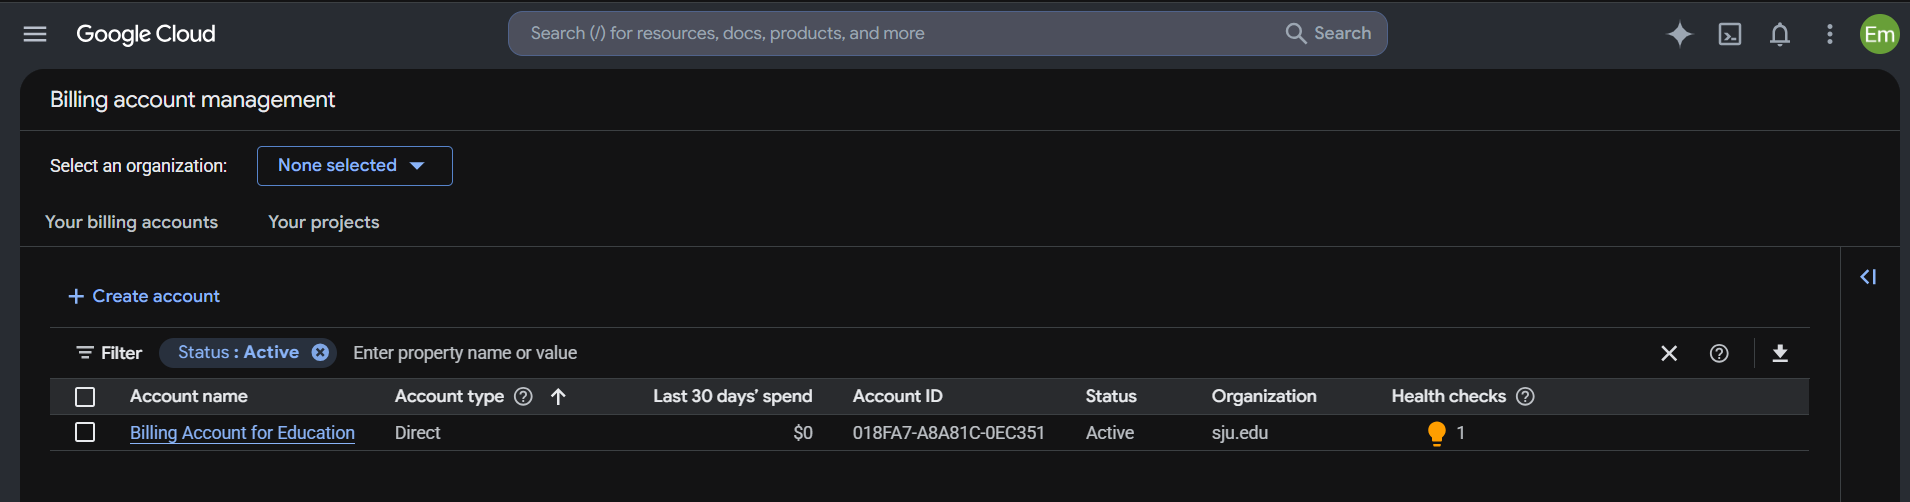

# Task 2
Load the dataset into a Pandas DataFrame using the official ucimlrepo package or direct data retrieval methods linked to the UCI repository.

In [20]:
!pip3 install -U ucimlrepo

In [21]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

data = fetch_ucirepo(id=360)
X = data.data.features
y = data.data.targets

df = pd.concat([X, y], axis=1)

# Task 3
Use structural inspection methods (head(), info(), describe()) to analyze the dataset structure and examine feature distributions across sensor and meteorological variables.

In [22]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


In [24]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


# Task 4
Identify and handle implicit missing data values (such as the standard -200 sentinel values present in the air quality dataset) and implement a structured imputation strategy using Scikit-Learn's SimpleImputer.

In [25]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(missing_values=-200, strategy='median')

# Using the SimpleImputer on numeric columns
numeric = df.select_dtypes(include=['int64','float64']).columns
df[numeric] = imputer.fit_transform(df[numeric])

# The min values are no longer -200 because I replaced the -200 values with
# the median.
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,2.089302,1098.392433,156.721599,10.009447,937.973923,235.178903,834.339959,112.373303,1456.528054,1020.562894,18.297574,49.248509,1.024352
std,1.323024,212.911465,67.058156,7.311771,261.625561,195.091025,251.808888,43.948519,339.370072,390.784960,8.658221,16.974949,0.395878
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.200000,941.000000,150.000000,4.600000,743.000000,112.000000,666.000000,86.000000,1242.000000,742.000000,12.000000,36.600000,0.746100
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.600000,1221.000000,150.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


# Task 5
Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (StandardScaler or MinMaxScaler) to numerical columns and necessary encoding to categorical/temporal features.

In [26]:
# I originally did these steps in task 6 (after the pipeline was set up),
# but I ran into errors because the CO(GT) column was still part of it

# Target binning
# Using pd.qcut() on CO (a continuous pollutant concentration value)
# to sort it into "good", "moderate", or "hazardous"
df['air_quality'] = pd.qcut(df['CO(GT)'], q=3, labels=['good', 'moderate', 'hazardous'])

# splitting them into X and y
# I also dropped CO(GT) because that's what I used for
# determining the air quality values
X = df.drop(columns=['air_quality', 'CO(GT)'])
y = df['air_quality']

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Isolate numerical & categorical features
numerical_data = X.select_dtypes(include=['int64','float64'])
categorical_data = X.select_dtypes(include='object')

print('Numerical:', numerical_data)
print('Categorical:', categorical_data)

Numerical:       PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  \
0          1360.0     150.0      11.9         1046.0    166.0        1056.0   
1          1292.0     112.0       9.4          955.0    103.0        1174.0   
2          1402.0      88.0       9.0          939.0    131.0        1140.0   
3          1376.0      80.0       9.2          948.0    172.0        1092.0   
4          1272.0      51.0       6.5          836.0    131.0        1205.0   
...           ...       ...       ...            ...      ...           ...   
9352       1314.0     150.0      13.5         1101.0    472.0         539.0   
9353       1163.0     150.0      11.4         1027.0    353.0         604.0   
9354       1142.0     150.0      12.4         1063.0    293.0         603.0   
9355       1003.0     150.0       9.5          961.0    235.0         702.0   
9356       1071.0     150.0      11.9         1047.0    265.0         654.0   

      NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)

In [28]:
# ColumnTransformer and Pipelines
# Something I did this time that I didn't do last time was
# including SimpleImputer steps in the pipelines to ensure
# there are no missing values

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_data.columns),
    ('cat', cat_pipeline, categorical_data.columns)
])

# Task 6
Train classification models to predict air quality categories using standard logistic/softmax regression and an SGDClassifier configured with custom loss functions and hyperparameters, evaluating convergence speed and performance.

In [29]:
from sklearn.model_selection import train_test_split

# Training the data with a 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logistic_regression = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42,
                                      max_iter=1000,
                                      penalty='l2'))
])

logistic_regression.fit(X_train, y_train)
y_pred = logistic_regression.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8536
              precision    recall  f1-score   support

        good       0.85      0.90      0.87       655
   hazardous       0.91      0.91      0.91       625
    moderate       0.79      0.74      0.77       592

    accuracy                           0.85      1872
   macro avg       0.85      0.85      0.85      1872
weighted avg       0.85      0.85      0.85      1872

[[590   3  62]
 [  5 567  53]
 [ 99  52 441]]


In [31]:
# SGD Classifier
from sklearn.linear_model import SGDClassifier

sgd_classifier = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(loss='log_loss',
                                 random_state=42,
                                 alpha=0.0001,
                                 penalty='l1'))
])

sgd_classifier.fit(X_train, y_train)
y_pred = sgd_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8413
              precision    recall  f1-score   support

        good       0.85      0.90      0.87       655
   hazardous       0.87      0.93      0.90       625
    moderate       0.80      0.69      0.74       592

    accuracy                           0.84      1872
   macro avg       0.84      0.84      0.84      1872
weighted avg       0.84      0.84      0.84      1872

[[587   3  65]
 [  7 581  37]
 [100  85 407]]


# Task 7
Transition to regression tasks to predict continuous pollutant concentrations, implementing baseline Linear Regression alongside Ridge (L2) and Lasso (L1) regularization, and analyzing how the regularization parameter impacts feature coefficients and feature selection.

In [32]:
# Linear regression
# CO(GT) is the target variable this time
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns=['CO(GT)'])
y = df['CO(GT)']

# Training the new X and y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear regression pipeline
linear_regression = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_regression.fit(X_train, y_train)
y_pred = linear_regression.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean squared error: {mse:.4f}')
print(f'R2 score: {r2:.4f}')

Mean squared error: 0.2057
R2 score: 0.8903


In [33]:
# Ridge regularization
ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=4))
])

ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean squared error: {mse:.4f}')
print(f'R2 score: {r2:.4f}')

Mean squared error: 0.2127
R2 score: 0.8866


In [34]:
# Lasso regularization

# The MSE was 1.7 when I used 1 as the value for alpha.
# Lasso had the most drastic difference from the original
# linear regression and the one using Ridge regularization
lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.001))
])

lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean squared error: {mse:.4f}')
print(f'R2 score: {r2:.4f}')

Mean squared error: 0.2347
R2 score: 0.8749


# Task 8
Provide a final documentation cell or appendix section containing a screenshot or export of your Google Cloud billing or resource utilization dashboard showing active credit consumption.
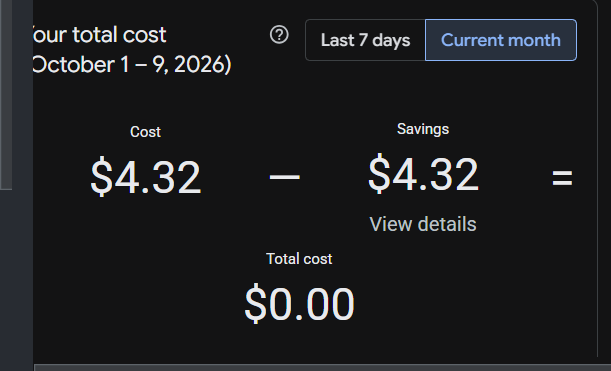
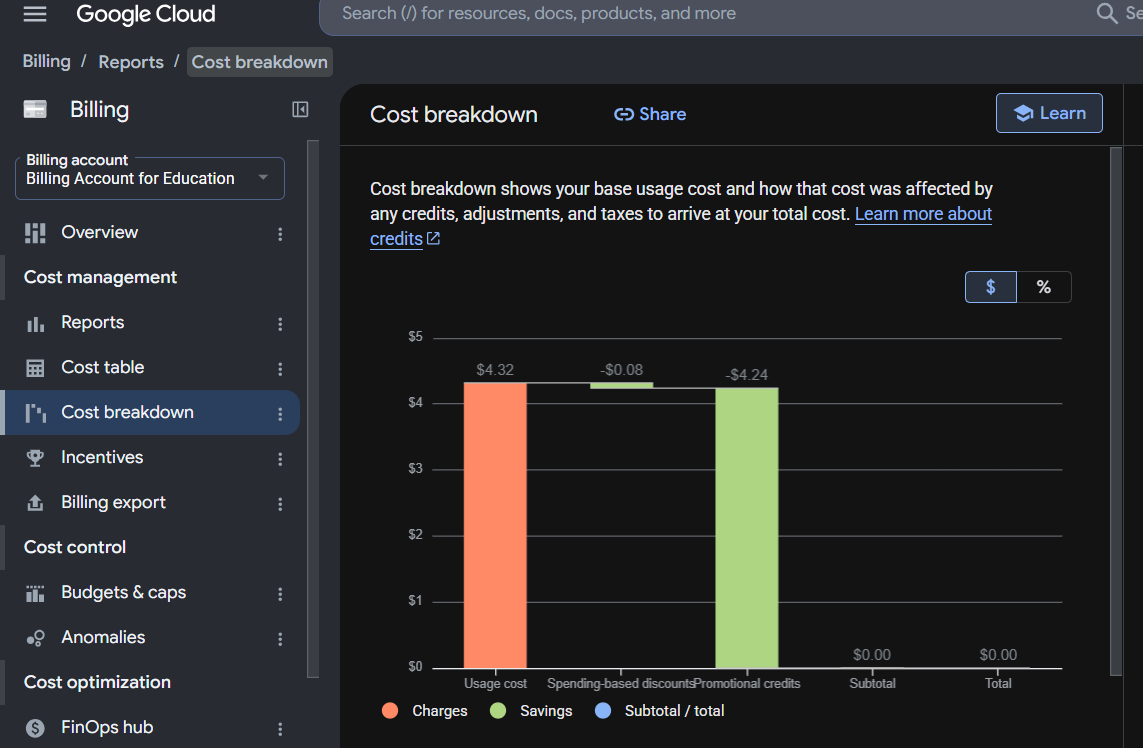